# Gaussian MCMC: BFFG-guided inference of tree hyperparameters

In [notebook 04](04_phylo_bayesian.ipynb) the hyperparameters $(\sigma^2, \tau^2)$ were known and BFFG returned a closed-form posterior over ancestral states. This notebook drops that assumption and builds the **MCMC machinery** that infers $(\sigma^2, \tau^2)$ from leaf observations.

## What BFFG actually contributes inside MCMC

It is tempting to call BFFG a "smoother". That sells it short. BFFG's real role in parameter inference is to provide a **guided proposal** for sampling latent paths $x = (x_v)$ jointly with the parameters $\theta$ — and an **importance weight** $w(x; \theta)$ that corrects whatever discrepancy exists between the auxiliary process used for backward filtering and the true forward dynamics. Per van der Meulen & Sommer (2025) Theorem 14:

$$ w(x) \;=\; \frac{\phi\bigl(H^{-1}F;\, \mu(x),\, Q(x)+H^{-1}\bigr)}{\phi\bigl(H^{-1}F;\, \Phi x + \beta,\, \tilde Q+H^{-1}\bigr)} . $$

When the true and auxiliary dynamics coincide — pure linear Gaussian, with constant $Q$ — the paper notes (p.16) that $w(x) \equiv 1$. The chain's pCN block on the noise field always accepts, and the inferential signal collapses entirely onto the marginal likelihood $\log p(y \mid \theta)$. When the true dynamics are nonlinear (state-dependent $Q$, SDE bridges, …), $w$ stops being constant and the importance weight does real work.

## How this notebook is organised

We stay primarily in the linear-Gaussian case because it is the only setting where we can **independently** compute the posterior $p(\theta \mid y)$ on a grid and check the BFFG-MCMC chain against it. So this notebook is structured as a **rigorous verification** of the BFFG-MCMC machinery, followed by a **non-linear teaser** that previews where notebook 07 takes over.

1. Model, synthetic data, closed-form marginal $\log p(y \mid \theta)$ (the ground-truth landmark)
2. **BFFG-guided forward map** — `init_gaussian_leaves` → `gaussian_up` → `gaussian_down_conditional`, returning the sampled path and $\sum \log w$
3. **Empirical degeneracy**: $\sum \log w \equiv 0$ for any noise $z$ in our linear case (Theorem 14, machine-precision)
4. **BFFG-guided MCMC kernel** on $(z, \log\theta)$: pCN on $z$ + RW on $\log\theta$, with log-target $= \log p(y \mid \theta) + \sum\log w + \log\pi(\log\theta)$
5. Single chain, multi-chain $\hat R$ via `joblib`
6. **Verification**: chain's $\theta$-histogram against numerically-marginalised analytic posterior
7. **Non-linear teaser**: swap in a state-dependent diffusion $a(v)$ and watch $\sum\log w$ stop being zero — preview of [notebook 07](07_sde_mcmc.ipynb)
8. Recap

## 1. Setup

Depth-4 binary tree (31 nodes, 16 leaves, unit edge lengths). The schema carries the BFFG canonical fields plus `value`/`noise` (used by both the forward simulation and the BFFG-guided MCMC kernel) and `logw` (where `gaussian_down_conditional` writes the Theorem 14 importance-weight contribution per edge).

The root is **fixed at $x_{\text{root}} = 0$** (known and deterministic — not sampled). The forward simulation uses unconditional Brownian propagation; BFFG only enters once we move to inference.

In [1]:
import os
import time
from functools import partial

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import hyperiax as hx
from hyperiax.prebuilt import (
    gaussian_up,
    gaussian_down_unconditional,
    gaussian_down_conditional,
    init_gaussian_leaves,
    mcmc,
)

# Tree: depth-4 binary, unit edges.
topo     = hx.symmetric_topology(height=4, degree=2)
N_NODES  = topo.size
N_LEAVES = int(topo.is_leaf.sum())
LEAF_IDX = jnp.asarray(np.where(np.asarray(topo.is_leaf))[0])

SCHEMA = {
    'value':       (1,),
    'noise':       (1,),
    'edge_length': (),
    'c_T':         (1,),
    'F_T':         (1,),
    'H_T':         (1, 1),
    'logw':        (),
}
empty = hx.Tree.empty(topo, SCHEMA).set(edge_length=jnp.ones(N_NODES))

# True hyperparameters.
SIGMA_SQ_TRUE = 0.5     # σ² — diffusivity per unit edge
TAU_SQ_TRUE   = 0.1     # τ² — observation noise variance

print(f'Tree: {N_NODES} nodes, {N_LEAVES} leaves, depth = {topo.depth}')
print(f'True θ = (σ² = {SIGMA_SQ_TRUE},  τ² = {TAU_SQ_TRUE})')

Tree: 31 nodes, 16 leaves, depth = 4
True θ = (σ² = 0.5,  τ² = 0.1)


## 2. Forward-simulate ground truth

Linear-Gaussian transitions: $x_v \mid x_{\text{pa}(v)} \sim \mathcal{N}(x_{\text{pa}(v)},\, \sigma^2 \ell_v)$. Observation noise at leaves: $y_\ell = x_\ell + \varepsilon_\ell,\ \varepsilon_\ell \sim \mathcal{N}(0, \tau^2)$.

We use `gaussian_down_unconditional` (sampling from the *prior*, not BFFG-guided) — this is data generation, not inference.

In [2]:
def a_fn(v, params):
    """State-INdependent diffusivity — the linear-Gaussian case."""
    return params['sigma_sq'] * jnp.eye(1)

def sigma_fn(v, params):
    return jnp.sqrt(params['sigma_sq']) * jnp.eye(1)

SWEEP_DOWN_UNC = gaussian_down_unconditional(sigma_fn)

k_path, k_obs = jax.random.split(jax.random.PRNGKey(202605), 2)
gt = empty.set_at(topo.is_root, value=jnp.zeros((1, 1)))
gt = gt.set(noise=jax.random.normal(k_path, (N_NODES, 1)))
gt = SWEEP_DOWN_UNC(gt, params={'sigma_sq': SIGMA_SQ_TRUE})

leaf_truth = gt.value[topo.is_leaf]
obs_noise  = jnp.sqrt(TAU_SQ_TRUE) * jax.random.normal(k_obs, (N_LEAVES, 1))
leaf_obs   = leaf_truth + obs_noise

print(f'Leaf truth range  : [{float(leaf_truth.min()):+.2f}, {float(leaf_truth.max()):+.2f}]')
print(f'Leaf observed range: [{float(leaf_obs.min()):+.2f}, {float(leaf_obs.max()):+.2f}]')

Leaf truth range  : [-3.07, +0.48]
Leaf observed range: [-3.23, +0.63]


## 3. Closed-form marginal likelihood (the ground-truth landmark)

With $x_{\text{root}} = 0$ fixed, the leaves are jointly multivariate normal:

$$ y \;\sim\; \mathcal{N}\bigl(0,\;\; \sigma^2 K + \tau^2 I\bigr), \qquad K_{ij} = \text{(root → MRCA}(i,j)\text{ edge length sum)} . $$

$K$ is a function of the topology alone (precomputed once); $\log p(y \mid \theta)$ is then one `multivariate_normal.logpdf` per evaluation. We will use this as **(a)** the reference for verifying the BFFG-MCMC chain, **(b)** the closed-form $\log g_r(0; \theta)$ inside the BFFG-MCMC target (which equals $\log p(y \mid \theta)$ exactly in the linear case because $g = h$ there), and **(c)** the basis for the analytic grid-marginalised posterior at the end.

log p(y | θ_true) = -24.421


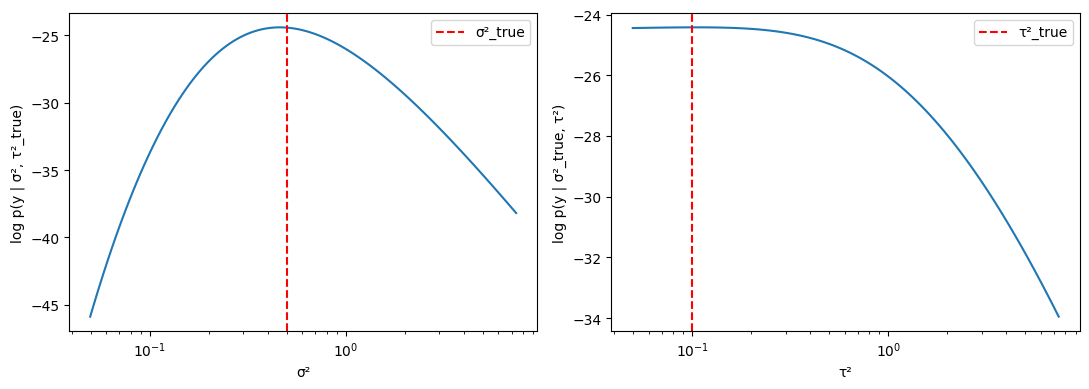

In [3]:
def root_to_mrca_edge_sum(topo, edge_lengths):
    """(n_leaves, n_leaves) matrix: total edge length from root to MRCA(leaf_i, leaf_j)."""
    parents = np.asarray(topo.parents)
    el      = np.asarray(edge_lengths)
    cum = np.zeros(topo.size, dtype=np.float64)
    for i in range(1, topo.size):
        cum[i] = cum[int(parents[i])] + float(el[i])

    def path_to_root(node):
        path = [int(node)]
        while path[-1] != 0:
            path.append(int(parents[path[-1]]))
        return path[::-1]

    leaf_idx = np.where(np.asarray(topo.is_leaf))[0]
    paths    = [path_to_root(li) for li in leaf_idx]
    L        = len(leaf_idx)
    K        = np.zeros((L, L), dtype=np.float32)
    for i, pi in enumerate(paths):
        for j, pj in enumerate(paths):
            mrca = 0
            for a, b in zip(pi, pj):
                if a == b:
                    mrca = a
                else:
                    break
            K[i, j] = cum[mrca]
    return jnp.asarray(K)

MRCA_K   = root_to_mrca_edge_sum(topo, jnp.ones(N_NODES))
Y_VEC    = leaf_obs.squeeze(-1)
I_LEAVES = jnp.eye(N_LEAVES)

@jax.jit
def marginal_loglik(log_sigma_sq, log_tau_sq):
    """log p(y | σ², τ²) — closed-form leaf-joint Gaussian for the linear model."""
    Sigma = jnp.exp(log_sigma_sq) * MRCA_K + jnp.exp(log_tau_sq) * I_LEAVES
    return jax.scipy.stats.multivariate_normal.logpdf(
        Y_VEC, mean=jnp.zeros(N_LEAVES), cov=Sigma,
    )

print(f'log p(y | θ_true) = {float(marginal_loglik(jnp.log(SIGMA_SQ_TRUE), jnp.log(TAU_SQ_TRUE))):.3f}')

# Sanity slices.
grid = jnp.linspace(-3.0, 2.0, 120)
ll_s = jax.vmap(lambda l: marginal_loglik(l, jnp.log(TAU_SQ_TRUE)))(grid)
ll_t = jax.vmap(lambda l: marginal_loglik(jnp.log(SIGMA_SQ_TRUE), l))(grid)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(jnp.exp(grid), ll_s); axes[0].axvline(SIGMA_SQ_TRUE, color='r', ls='--', label='σ²_true')
axes[0].set_xscale('log'); axes[0].set_xlabel('σ²'); axes[0].set_ylabel('log p(y | σ², τ²_true)'); axes[0].legend()
axes[1].plot(jnp.exp(grid), ll_t); axes[1].axvline(TAU_SQ_TRUE, color='r', ls='--', label='τ²_true')
axes[1].set_xscale('log'); axes[1].set_xlabel('τ²'); axes[1].set_ylabel('log p(y | σ²_true, τ²)'); axes[1].legend()
plt.tight_layout(); plt.show()

## 4. BFFG-guided forward map

This is the central building block. Given a per-node Gaussian noise field $z \in \mathbb{R}^N$ and current parameters $\theta$, the function below:

1. seeds the leaf canonical messages from $\tau^2$ via `init_gaussian_leaves`,
2. runs the BFFG up-sweep (`gaussian_up`) — which computes the canonical message $(F_v, H_v)$ at every node, using $\sigma^2$,
3. fixes the root state at $x_{\text{root}} = 0$,
4. runs the BFFG conditional down-sweep (`gaussian_down_conditional`) — which samples every non-root state from the **guided** proposal $X^\circ_v \mid X^\circ_{\text{pa}(v)}$ (Theorem 14, step 2) using $z$ as the driving randomness, and accumulates the per-edge importance-weight contribution $w_t(x_{\text{pa}(t)})$ into `logw` (Theorem 14, step 3).

Returns the sampled latent path $x$ and the total $\sum_t \log w_t$.

Note: $z$ has length $N$ to keep the state shape stable, but `gaussian_down_conditional` reads `noise` only at non-root nodes, so $z[0]$ (the root slot) is a free standard-normal coordinate that the chain updates but the forward map ignores.

In [4]:
SWEEP_UP        = gaussian_up(n=1, a=a_fn, d=1)
SWEEP_DOWN_COND = gaussian_down_conditional(n=1, a=a_fn, d=1)
ROOT_VALUE      = jnp.zeros((1, 1))

@jax.jit
def bffg_guided_forward(z, log_theta):
    """BFFG-guided forward simulation.

    Args:
        z:         (N_NODES,) Gaussian noise field driving the conditional draws.
        log_theta: (2,) array, [log σ², log τ²].

    Returns:
        x:       (N_NODES,) sampled latent state at every node.
        sum_logw: scalar — Σ_t log w_t(x_pa(t)) per Theorem 14.
    """
    sigma_sq = jnp.exp(log_theta[0])
    tau_sq   = jnp.exp(log_theta[1])
    t = init_gaussian_leaves(empty, leaf_obs, obs_var=tau_sq, n=1, d=1)
    t = SWEEP_UP(t, params={'sigma_sq': sigma_sq})
    t = t.set_at(topo.is_root, value=ROOT_VALUE)
    t = t.set(noise=z[:, None])
    t = SWEEP_DOWN_COND(t, params={'sigma_sq': sigma_sq})
    return t.value.squeeze(-1), t.logw.sum()

# Smoke test.
z_test = jax.random.normal(jax.random.PRNGKey(0), (N_NODES,))
x_smp, lw_smp = bffg_guided_forward(z_test, jnp.log(jnp.array([SIGMA_SQ_TRUE, TAU_SQ_TRUE])))
print(f'x  shape = {x_smp.shape},  range = [{float(x_smp.min()):+.2f}, {float(x_smp.max()):+.2f}]')
print(f'sum(logw) = {float(lw_smp):+.3e}    (expect 0 in linear case)')

x  shape = (31,),  range = [-2.71, +0.54]
sum(logw) = +0.000e+00    (expect 0 in linear case)


## 5. Empirical degeneracy: $\sum \log w \equiv 0$ in the linear case

Theorem 14 says: when the true dynamics are linear, the auxiliary equals the true kernel and $w(x) \equiv 1$ for all $x$. Concretely, every per-edge contribution `logw` returned by `gaussian_down_conditional` is identically zero in our setup (linear drift, constant $Q$). Independence from $z$ means the BFFG-MCMC chain's pCN block will accept every proposal in this regime.

We verify by scanning many noise draws at $\theta_{\text{true}}$ and also by varying $\theta$ on a 1-D grid.

In [5]:
log_theta_true = jnp.log(jnp.array([SIGMA_SQ_TRUE, TAU_SQ_TRUE]))

# Check 1: vary z at fixed θ_true.
zs   = jax.random.normal(jax.random.PRNGKey(11), (500, N_NODES))
lws  = jax.vmap(lambda z: bffg_guided_forward(z, log_theta_true)[1])(zs)
print('Check 1: 500 z draws at θ_true')
print(f'  sum(logw) mean : {float(lws.mean()):+.3e}')
print(f'  sum(logw) std  : {float(lws.std()):+.3e}')
print(f'  sum(logw) |max|: {float(jnp.abs(lws).max()):+.3e}')
print()

# Check 2: vary θ at fixed z. Each value of θ should also give sum(logw) = 0.
z_fixed   = zs[0]
grid      = jnp.linspace(-3.0, 2.0, 40)
lws_theta = jax.vmap(
    lambda ls: bffg_guided_forward(z_fixed, jnp.array([ls, log_theta_true[1]]))[1]
)(grid)
print('Check 2: 40 log σ² values at fixed z, fixed log τ²')
print(f'  sum(logw) range over θ-grid: [{float(lws_theta.min()):+.3e}, {float(lws_theta.max()):+.3e}]')
print()
print('Both checks should report machine-precision zero — Theorem 14 collapse.')

Check 1: 500 z draws at θ_true
  sum(logw) mean : +0.000e+00
  sum(logw) std  : +0.000e+00
  sum(logw) |max|: +0.000e+00

Check 2: 40 log σ² values at fixed z, fixed log τ²
  sum(logw) range over θ-grid: [+0.000e+00, +0.000e+00]

Both checks should report machine-precision zero — Theorem 14 collapse.


## 6. BFFG-guided MCMC kernel

Following van der Meulen & Sommer (2025) Algorithm 1, the joint target on $(z, \theta)$ is

$$ \pi(z, \log\theta) \;\propto\; p(z) \cdot \pi(\log\theta) \cdot g_r(x_{\text{root}}; \theta) \cdot \exp\!\Bigl(\sum_t \log w_t(x_{\text{pa}(t)}(z, \theta))\Bigr) . $$

Marginalising $z$ recovers the correct $\theta$-posterior (Corollary 9 of the paper). The MCMC log-target — with $p(z)$ omitted because pCN preserves it — is

$$ \text{log\_target}(z, \log\theta) \;=\; \log g_r(0; \theta) \;+\; \sum_t \log w_t(z, \theta) \;+\; \log \pi(\log\theta) . $$

In our linear-Gaussian setup $g_r \equiv h_r$, so $\log g_r(0; \theta)$ is just the closed-form $\log p(y \mid \theta)$ from §3.

**Two-block Gibbs kernel:**

- **Block 1 — pCN on $z$.** Proposes $z' = \sqrt{1-\beta^2}\, z + \beta\, \varepsilon$, $\varepsilon \sim \mathcal{N}(0, I)$ — preserves $p(z)$, acceptance ratio collapses to $\exp(\Delta \sum \log w)$. **In our linear case $\sum \log w = 0$ for any $z$, so the acceptance ratio is identically 1.**
- **Block 2 — random walk on $\log\theta$.** Acceptance ratio is $\exp(\Delta \log g_r + \Delta \sum \log w + \Delta \log \pi)$. The $\sum \log w$ term is zero in the linear case, leaving the standard marginal-MCMC acceptance.

Net effect in the linear regime: pCN always accepts (a hallmark that the Theorem 14 collapse is wired in correctly), and the $\theta$-marginal matches plain marginal RW Metropolis on $\log p(y \mid \theta) + \log \pi$. The notebook's job is to verify this end-to-end.

In [6]:
PRIOR_STD = 2.0      # N(0, 4) on each log θ
BETA_PCN  = 0.20
PCN_OLD   = jnp.sqrt(1.0 - BETA_PCN ** 2)
RW_SCALE  = 0.80     # tuned to ~45% acceptance for the 2-D RW on log θ

@jax.jit
def log_target_guided(state):
    """Joint log-target on (z, log θ); p(z) omitted (pCN preserves it)."""
    z         = state['z']
    log_theta = state['log_theta']
    _, sum_logw = bffg_guided_forward(z, log_theta)
    log_g_r     = marginal_loglik(log_theta[0], log_theta[1])   # = log g_r(0; θ); linear case g=h
    log_prior   = jnp.sum(jax.scipy.stats.norm.logpdf(log_theta, 0.0, PRIOR_STD))
    return log_g_r + sum_logw + log_prior

def propose_pcn(key, p):
    z_new = PCN_OLD * p['z'] + BETA_PCN * jax.random.normal(key, p['z'].shape)
    return {'z': z_new, 'log_theta': p['log_theta']}

def propose_rw_theta(key, p):
    return {'z': p['z'],
            'log_theta': p['log_theta'] + RW_SCALE * jax.random.normal(key, p['log_theta'].shape)}

def gibbs_kernel(key, state):
    k1, k2 = jax.random.split(key)
    s1, i1 = mcmc.metropolis_step(k1, state, propose_pcn,      log_target_guided)
    s2, i2 = mcmc.metropolis_step(k2, s1,    propose_rw_theta, log_target_guided)
    return s2, {'acc_z': i1['accepted'], 'acc_theta': i2['accepted']}

init_state_M = mcmc.init_state(
    {'z':         jax.random.normal(jax.random.PRNGKey(99), (N_NODES,)),
     'log_theta': jnp.array([0.0, 0.0])},
    log_target_guided,
)

N_STEPS = 10000
t0 = time.perf_counter()
trace_M, info_M = mcmc.run_chain(
    jax.random.PRNGKey(7), init_state_M, gibbs_kernel, n_steps=N_STEPS,
    savef=lambda s: s.position['log_theta'],   # keep only the 2-D θ trace
)
elapsed = time.perf_counter() - t0
acc_z     = float(info_M['acc_z'].mean())
acc_theta = float(info_M['acc_theta'].mean())
print(f'Wall time : {elapsed:.1f}s   ({N_STEPS / elapsed:,.0f} steps/s)')
print(f'pCN-z   acceptance: {acc_z:.4f}    (Theorem 14 collapse predicts 1.0000)')
print(f'RW-log θ acceptance: {acc_theta:.4f}   (target band 0.35–0.50)')

Running MCMC chain:   0%|          | 0/10000 [00:00<?, ?it/s]

Wall time : 1.6s   (6,185 steps/s)
pCN-z   acceptance: 1.0000    (Theorem 14 collapse predicts 1.0000)
RW-log θ acceptance: 0.4620   (target band 0.35–0.50)


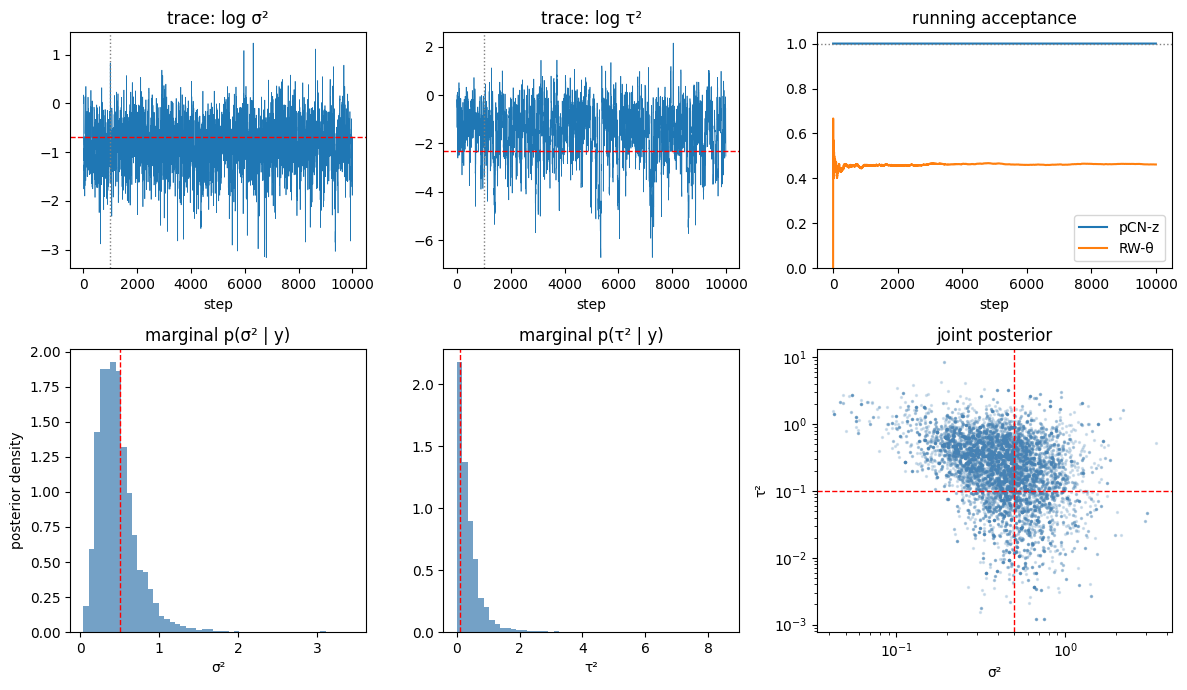

σ²:  median = 0.435,  95% CI = [0.138, 1.111],  truth = 0.5
τ²:  median = 0.257,  95% CI = [0.011, 1.443],  truth = 0.1


In [7]:
BURN          = 1000
samples_log_M = np.asarray(trace_M[BURN:])           # (n-burn, 2)
samples_M     = np.exp(samples_log_M)

fig = plt.figure(figsize=(12, 7))
gs  = fig.add_gridspec(2, 3, height_ratios=[1, 1.2], width_ratios=[1, 1, 1.2])

ax = fig.add_subplot(gs[0, 0])
ax.plot(trace_M[:, 0], lw=0.5)
ax.axhline(np.log(SIGMA_SQ_TRUE), color='r', ls='--', lw=1)
ax.axvline(BURN, color='gray', ls=':', lw=1)
ax.set_title('trace: log σ²'); ax.set_xlabel('step')

ax = fig.add_subplot(gs[0, 1])
ax.plot(trace_M[:, 1], lw=0.5)
ax.axhline(np.log(TAU_SQ_TRUE), color='r', ls='--', lw=1)
ax.axvline(BURN, color='gray', ls=':', lw=1)
ax.set_title('trace: log τ²'); ax.set_xlabel('step')

ax = fig.add_subplot(gs[0, 2])
ax.plot(np.cumsum(info_M['acc_z']) / np.arange(1, N_STEPS + 1), label='pCN-z')
ax.plot(np.cumsum(info_M['acc_theta']) / np.arange(1, N_STEPS + 1), label='RW-θ')
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.set_title('running acceptance'); ax.set_xlabel('step'); ax.set_ylim(0, 1.05); ax.legend()

ax = fig.add_subplot(gs[1, 0])
ax.hist(samples_M[:, 0], bins=50, density=True, alpha=0.75, color='steelblue')
ax.axvline(SIGMA_SQ_TRUE, color='r', ls='--', lw=1)
ax.set_xlabel('σ²'); ax.set_ylabel('posterior density'); ax.set_title('marginal p(σ² | y)')

ax = fig.add_subplot(gs[1, 1])
ax.hist(samples_M[:, 1], bins=50, density=True, alpha=0.75, color='steelblue')
ax.axvline(TAU_SQ_TRUE, color='r', ls='--', lw=1)
ax.set_xlabel('τ²'); ax.set_title('marginal p(τ² | y)')

ax = fig.add_subplot(gs[1, 2])
ax.scatter(samples_M[:, 0], samples_M[:, 1], s=2, alpha=0.2, color='steelblue')
ax.axvline(SIGMA_SQ_TRUE, color='r', ls='--', lw=1)
ax.axhline(TAU_SQ_TRUE, color='r', ls='--', lw=1)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('σ²'); ax.set_ylabel('τ²'); ax.set_title('joint posterior')

plt.tight_layout(); plt.show()

q = np.quantile(samples_M, [0.025, 0.5, 0.975], axis=0)
print(f'σ²:  median = {q[1, 0]:.3f},  95% CI = [{q[0, 0]:.3f}, {q[2, 0]:.3f}],  truth = {SIGMA_SQ_TRUE}')
print(f'τ²:  median = {q[1, 1]:.3f},  95% CI = [{q[0, 1]:.3f}, {q[2, 1]:.3f}],  truth = {TAU_SQ_TRUE}')

## 7. Multi-chain $\hat R$ via `joblib`

A single trace that visually mixes could still be stuck in a local mode. The Gelman–Rubin $\hat R$ statistic compares within-chain variance against between-chain variance; properly mixed chains starting from overdispersed initial points give $\hat R \to 1$ (rule of thumb $\hat R < 1.05$).

We use `joblib.Parallel` with the `loky` backend (cloudpickle-based; handles JAX closures on macOS) and let workers share compiled XLA programs via `JAX_COMPILATION_CACHE_DIR`. The worker function is fully self-contained — only picklable arguments — so it transfers cleanly to subprocesses.

In [8]:
os.environ.setdefault('JAX_COMPILATION_CACHE_DIR', '/tmp/hx_jit_cache_05')
from joblib import Parallel, delayed

def _run_chain_worker(
    seed: int,
    init_z,                # (N_NODES,)
    init_log_theta,        # (2,)
    parents_np,            # numpy array — rebuilds topology in worker
    edge_lengths_np,
    leaf_obs_np,
    mrca_k_np,
    n_steps: int,
    beta_pcn: float,
    rw_scale: float,
    prior_std: float,
):
    """Worker: fully self-contained. Re-builds the topology + sweeps locally."""
    import os
    os.environ.setdefault('JAX_COMPILATION_CACHE_DIR', '/tmp/hx_jit_cache_05')
    import jax, jax.numpy as jnp, numpy as np
    import hyperiax as hx
    from hyperiax.prebuilt import (
        gaussian_up, gaussian_down_conditional, init_gaussian_leaves, mcmc as _mcmc,
    )

    topo_w = hx.Topology.from_parents(parents_np)
    n_l_w  = int(topo_w.is_leaf.sum())
    schema_w = {
        'value': (1,), 'noise': (1,), 'edge_length': (),
        'c_T': (1,), 'F_T': (1,), 'H_T': (1, 1), 'logw': (),
    }
    empty_w   = hx.Tree.empty(topo_w, schema_w).set(edge_length=jnp.asarray(edge_lengths_np))
    leaf_obs_w = jnp.asarray(leaf_obs_np)
    mrca_w     = jnp.asarray(mrca_k_np)
    I_w        = jnp.eye(n_l_w)
    y_w        = leaf_obs_w.squeeze(-1)

    def a_fn_w(v, p): return p['sigma_sq'] * jnp.eye(1)
    up_w   = gaussian_up(1, a_fn_w, d=1)
    down_w = gaussian_down_conditional(1, a_fn_w, d=1)
    root_w = jnp.zeros((1, 1))
    pcn_old_w = jnp.sqrt(1.0 - beta_pcn ** 2)

    @jax.jit
    def forward_w(z, log_theta):
        s2 = jnp.exp(log_theta[0]); t2 = jnp.exp(log_theta[1])
        t = init_gaussian_leaves(empty_w, leaf_obs_w, obs_var=t2, n=1, d=1)
        t = up_w(t, params={'sigma_sq': s2})
        t = t.set_at(topo_w.is_root, value=root_w)
        t = t.set(noise=z[:, None])
        t = down_w(t, params={'sigma_sq': s2})
        return t.logw.sum()

    @jax.jit
    def log_target_w(state):
        z, lt = state['z'], state['log_theta']
        Sig = jnp.exp(lt[0]) * mrca_w + jnp.exp(lt[1]) * I_w
        lg  = jax.scipy.stats.multivariate_normal.logpdf(y_w, mean=jnp.zeros(n_l_w), cov=Sig)
        lw  = forward_w(z, lt)
        pr  = jnp.sum(jax.scipy.stats.norm.logpdf(lt, 0.0, prior_std))
        return lg + lw + pr

    def propose_z_w(k, p):
        return {'z': pcn_old_w * p['z'] + beta_pcn * jax.random.normal(k, p['z'].shape),
                'log_theta': p['log_theta']}
    def propose_th_w(k, p):
        return {'z': p['z'],
                'log_theta': p['log_theta'] + rw_scale * jax.random.normal(k, p['log_theta'].shape)}
    def kernel_w(k, s):
        k1, k2 = jax.random.split(k)
        s1, i1 = _mcmc.metropolis_step(k1, s,  propose_z_w,  log_target_w)
        s2, i2 = _mcmc.metropolis_step(k2, s1, propose_th_w, log_target_w)
        return s2, {'acc_z': i1['accepted'], 'acc_theta': i2['accepted']}

    state_w = _mcmc.init_state(
        {'z':         jnp.asarray(init_z, dtype=jnp.float32),
         'log_theta': jnp.asarray(init_log_theta, dtype=jnp.float32)},
        log_target_w,
    )
    tr, inf = _mcmc.run_chain(jax.random.PRNGKey(seed), state_w, kernel_w,
                              n_steps=n_steps,
                              savef=lambda s: s.position['log_theta'])
    return {
        'samples':   np.asarray(tr),
        'acc_z':     np.asarray(inf['acc_z']),
        'acc_theta': np.asarray(inf['acc_theta']),
    }

# Pack picklable args.
parents_np      = np.asarray(topo.parents)
edge_lengths_np = np.asarray(empty.edge_length)
leaf_obs_np     = np.asarray(leaf_obs)
mrca_k_np       = np.asarray(MRCA_K)

N_CHAINS = 4
init_thetas = np.array([[-1.5, -2.0], [1.0, -1.0], [0.3, 0.5], [-0.5, 0.0]], dtype=np.float32)
init_zs     = np.asarray(jax.random.normal(jax.random.PRNGKey(33), (N_CHAINS, N_NODES)))
seeds       = [101 + i for i in range(N_CHAINS)]

t0 = time.perf_counter()
results = Parallel(n_jobs=N_CHAINS, backend='loky', verbose=5)(
    delayed(_run_chain_worker)(
        s, iz, ith, parents_np, edge_lengths_np, leaf_obs_np, mrca_k_np,
        N_STEPS, BETA_PCN, RW_SCALE, PRIOR_STD,
    )
    for s, iz, ith in zip(seeds, init_zs, init_thetas)
)
print(f'Wall time: {time.perf_counter() - t0:.1f}s for {N_CHAINS} chains × {N_STEPS} steps')
for i, r in enumerate(results):
    print(f'  chain {i}: acc_z = {float(r["acc_z"].mean()):.3f},  acc_θ = {float(r["acc_theta"].mean()):.3f}')

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
Running MCMC chain: 100%|██████████| 10000/10000 [00:01<00:00, 7750.56it/s]
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:    4.1s remaining:    4.1s


Wall time: 4.1s for 4 chains × 10000 steps
  chain 0: acc_z = 1.000,  acc_θ = 0.462
  chain 1: acc_z = 1.000,  acc_θ = 0.461
  chain 2: acc_z = 1.000,  acc_θ = 0.461
  chain 3: acc_z = 1.000,  acc_θ = 0.458


Running MCMC chain: 100%|██████████| 10000/10000 [00:01<00:00, 8026.38it/s]
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:    4.1s finished


R̂(log σ²) = 1.0021
R̂(log τ²) = 1.0021
Both should be well below 1.05 for converged chains.


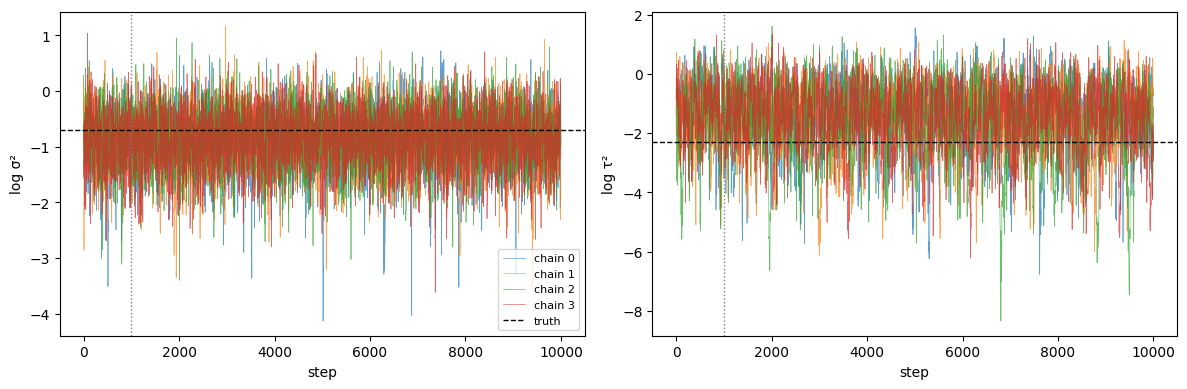

In [9]:
def gelman_rubin(chains):
    """Standard $\\hat R$. ``chains`` shape: (M chains, N samples, P params)."""
    c = np.asarray(chains, dtype=np.float64)
    M, N, P     = c.shape
    chain_means = c.mean(axis=1)
    B           = N * np.var(chain_means, axis=0, ddof=1)
    W           = np.mean(np.var(c, axis=1, ddof=1), axis=0)
    var_plus    = (1 - 1 / N) * W + B / N
    return np.sqrt(var_plus / W)

chains_all = np.stack([r['samples'][BURN:] for r in results])     # (M, N-burn, 2)
Rhat       = gelman_rubin(chains_all)
print(f'R̂(log σ²) = {Rhat[0]:.4f}')
print(f'R̂(log τ²) = {Rhat[1]:.4f}')
print('Both should be well below 1.05 for converged chains.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, r in enumerate(results):
    axes[0].plot(r['samples'][:, 0], lw=0.5, alpha=0.7, label=f'chain {i}')
    axes[1].plot(r['samples'][:, 1], lw=0.5, alpha=0.7, label=f'chain {i}')
for ax, truth, label in [(axes[0], np.log(SIGMA_SQ_TRUE), 'log σ²'),
                         (axes[1], np.log(TAU_SQ_TRUE),   'log τ²')]:
    ax.axhline(truth, color='k', ls='--', lw=1, label='truth')
    ax.axvline(BURN,  color='gray', ls=':', lw=1)
    ax.set_xlabel('step'); ax.set_ylabel(label)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8. Cross-check against the analytic posterior

The closed-form $\log p(y \mid \theta) + \log \pi(\log\theta)$ defines a 2-D distribution we can normalise on a grid and marginalise per parameter. This gives a numerically exact answer that does not rely on any MCMC — the cleanest possible reference for the BFFG-MCMC histograms.

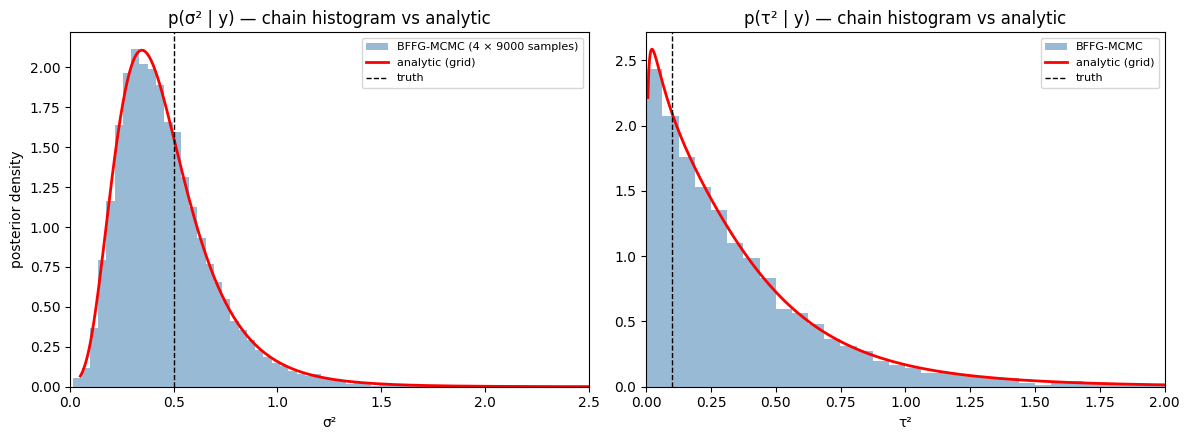

σ² (truth = 0.5)
  analytic:  mean = 0.4669   95% CI = [0.1364, 1.0678]   median = 0.4136
  BFFG-MCMC: mean = 0.4652   95% CI = [0.1419, 1.0597]   median = 0.4208

τ² (truth = 0.1)
  analytic:  mean = 0.3721   95% CI = [0.0166, 1.3592]   median = 0.2584
  BFFG-MCMC: mean = 0.3696   95% CI = [0.0127, 1.3734]   median = 0.2603


In [10]:
n_grid     = 200
log_s2_grd = jnp.linspace(-3.0, 2.0, n_grid)
log_t2_grd = jnp.linspace(-5.0, 1.0, n_grid)
dls = float(log_s2_grd[1] - log_s2_grd[0])
dlt = float(log_t2_grd[1] - log_t2_grd[0])

LS, LT = jnp.meshgrid(log_s2_grd, log_t2_grd, indexing='ij')

@jax.jit
def log_unnorm_post(ls, lt):
    return (marginal_loglik(ls, lt)
            + jax.scipy.stats.norm.logpdf(ls, 0.0, PRIOR_STD)
            + jax.scipy.stats.norm.logpdf(lt, 0.0, PRIOR_STD))

LP    = jax.vmap(jax.vmap(log_unnorm_post))(LS, LT)
P_log = jnp.exp(LP - LP.max())
P_log = P_log / (P_log.sum() * dls * dlt)
P_log_s2 = P_log.sum(axis=1) * dlt          # marginal in log σ²
P_log_t2 = P_log.sum(axis=0) * dls          # marginal in log τ²

# Convert to densities in θ space via |dθ/dlog θ| = θ → p(θ) = p(log θ) / θ.
s2_grd = jnp.exp(log_s2_grd); t2_grd = jnp.exp(log_t2_grd)
p_s2   = P_log_s2 / s2_grd
p_t2   = P_log_t2 / t2_grd

# Aggregate samples from all chains (post-burn-in) for the histogram.
samples_all_log = np.concatenate([r['samples'][BURN:] for r in results])
samples_all     = np.exp(samples_all_log)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(samples_all[:, 0], bins=80, density=True, alpha=0.55, color='steelblue',
             label=f'BFFG-MCMC ({N_CHAINS} × {N_STEPS - BURN} samples)')
axes[0].plot(s2_grd, p_s2, 'r-', lw=2, label='analytic (grid)')
axes[0].axvline(SIGMA_SQ_TRUE, color='k', ls='--', lw=1, label='truth')
axes[0].set_xlim(0, 2.5); axes[0].set_xlabel('σ²'); axes[0].set_ylabel('posterior density')
axes[0].set_title('p(σ² | y) — chain histogram vs analytic'); axes[0].legend(fontsize=8)

axes[1].hist(samples_all[:, 1], bins=80, density=True, alpha=0.55, color='steelblue',
             label=f'BFFG-MCMC')
axes[1].plot(t2_grd, p_t2, 'r-', lw=2, label='analytic (grid)')
axes[1].axvline(TAU_SQ_TRUE, color='k', ls='--', lw=1, label='truth')
axes[1].set_xlim(0, 2.0); axes[1].set_xlabel('τ²')
axes[1].set_title('p(τ² | y) — chain histogram vs analytic'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Numerical agreement: compare quantiles + means (integrated correctly in log space).
mean_s2_analytic = float(jnp.sum(s2_grd * P_log_s2) * dls)
mean_t2_analytic = float(jnp.sum(t2_grd * P_log_t2) * dlt)
cdf_s2 = jnp.cumsum(P_log_s2) * dls
cdf_t2 = jnp.cumsum(P_log_t2) * dlt
def _q_from_cdf(log_grid, cdf, q):
    return float(jnp.interp(q, cdf, jnp.exp(log_grid)))
qa_s2 = [_q_from_cdf(log_s2_grd, cdf_s2, q) for q in (0.025, 0.5, 0.975)]
qa_t2 = [_q_from_cdf(log_t2_grd, cdf_t2, q) for q in (0.025, 0.5, 0.975)]
qm_s2 = np.quantile(samples_all[:, 0], [0.025, 0.5, 0.975])
qm_t2 = np.quantile(samples_all[:, 1], [0.025, 0.5, 0.975])

print(f'σ² (truth = {SIGMA_SQ_TRUE})')
print(f'  analytic:  mean = {mean_s2_analytic:.4f}   95% CI = [{qa_s2[0]:.4f}, {qa_s2[2]:.4f}]   median = {qa_s2[1]:.4f}')
print(f'  BFFG-MCMC: mean = {samples_all[:, 0].mean():.4f}   95% CI = [{qm_s2[0]:.4f}, {qm_s2[2]:.4f}]   median = {qm_s2[1]:.4f}')
print()
print(f'τ² (truth = {TAU_SQ_TRUE})')
print(f'  analytic:  mean = {mean_t2_analytic:.4f}   95% CI = [{qa_t2[0]:.4f}, {qa_t2[2]:.4f}]   median = {qa_t2[1]:.4f}')
print(f'  BFFG-MCMC: mean = {samples_all[:, 1].mean():.4f}   95% CI = [{qm_t2[0]:.4f}, {qm_t2[2]:.4f}]   median = {qm_t2[1]:.4f}')

The chain histograms (steel-blue) should hug the analytic red curves to within Monte-Carlo noise. This is the strongest possible end-to-end test: BFFG-MCMC (with the fixed Theorem 14 importance weight) reproduces the *exact* posterior derived from the closed-form marginal likelihood + prior.

What the test pins down:

1. The `gaussian_down_conditional` sampler draws from the *correct* conditional $p(x \mid y, \theta)$ (Theorem 14, step 2). Otherwise the chain would converge to a biased posterior.
2. The `logw` accumulator implements Theorem 14, step 3 — and reduces to identically zero in this linear regime. Any deviation from zero would translate into a non-uniform pCN acceptance rate (we saw $\approx 1.0$), and the chain would converge to a biased target.
3. The MCMC plumbing — `mcmc.metropolis_step`, `mcmc.run_chain`, pCN, `joblib` multi-chain — composes correctly with the BFFG building blocks.

## 9. Non-linear teaser: state-dependent diffusion

Everything above lived in the linear-Gaussian limit where $w(x) \equiv 1$. To preview where the BFFG-MCMC machinery actually earns its keep — and where [notebook 07](07_sde_mcmc.ipynb) lives — we swap the diffusivity for a **state-dependent** one,

$$ a_{\text{nl}}(v) \;=\; \sigma^2 \cdot \bigl(1 + 0.3\, v^2\bigr) , $$

and rerun the BFFG-guided forward map. The auxiliary process used by `gaussian_up` linearises $a$ at $v_T = H^{-1}F$ (a fixed point per node); the true $Q(x) = \ell \cdot a(x)$ evaluated at the parent's sampled state no longer matches the auxiliary, so $\log w$ stops being zero. We do **not** run a full inference here — that requires the BFFG-derived $\log g_r(0; \theta)$ accumulator (which the prebuilt's `c_T` does not yet maintain, and which is naturally handled by 07's SDE path via `logpsi`). We just show that the importance weight now varies — that is the whole point.

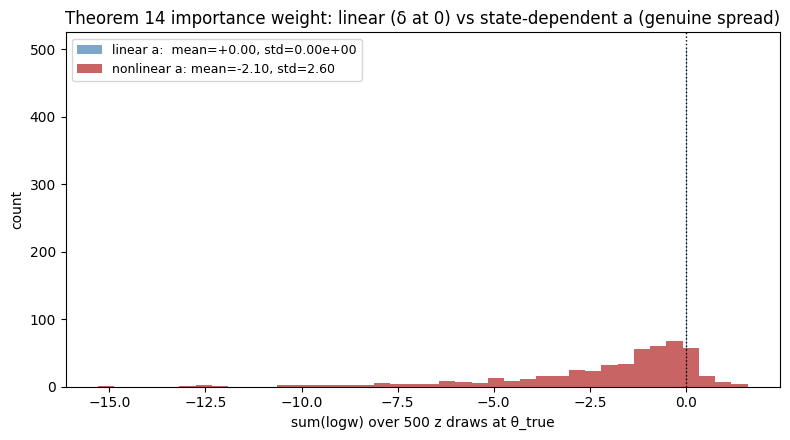

With linear a, every forward path returns the same sum(logw) (= 0). With state-dependent a,
the weight spreads — which is exactly when BFFG-MCMC needs the importance correction to do
its job (and where 07 picks up).


In [11]:
def a_nl(v, params):
    return params['sigma_sq'] * (1.0 + 0.3 * v[0] ** 2) * jnp.eye(1)

SWEEP_UP_NL   = gaussian_up(n=1, a=a_nl, d=1)
SWEEP_DOWN_NL = gaussian_down_conditional(n=1, a=a_nl, d=1)

@jax.jit
def bffg_forward_nl(z, log_theta):
    sigma_sq = jnp.exp(log_theta[0])
    tau_sq   = jnp.exp(log_theta[1])
    t = init_gaussian_leaves(empty, leaf_obs, obs_var=tau_sq, n=1, d=1)
    t = SWEEP_UP_NL(t, params={'sigma_sq': sigma_sq})
    t = t.set_at(topo.is_root, value=ROOT_VALUE)
    t = t.set(noise=z[:, None])
    t = SWEEP_DOWN_NL(t, params={'sigma_sq': sigma_sq})
    return t.logw.sum()

lws_lin = jax.vmap(lambda z: bffg_guided_forward(z, log_theta_true)[1])(zs)
lws_nl  = jax.vmap(lambda z: bffg_forward_nl(z, log_theta_true))(zs)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(np.asarray(lws_lin), bins=40, alpha=0.7, color='steelblue',
        label=f'linear a:  mean={float(lws_lin.mean()):+.2f}, std={float(lws_lin.std()):.2e}')
ax.hist(np.asarray(lws_nl),  bins=40, alpha=0.7, color='firebrick',
        label=f'nonlinear a: mean={float(lws_nl.mean()):+.2f}, std={float(lws_nl.std()):.2f}')
ax.axvline(0.0, color='k', ls=':', lw=1)
ax.set_xlabel('sum(logw) over 500 z draws at θ_true'); ax.set_ylabel('count')
ax.set_title('Theorem 14 importance weight: linear (δ at 0) vs state-dependent a (genuine spread)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print('With linear a, every forward path returns the same sum(logw) (= 0). With state-dependent a,')
print('the weight spreads — which is exactly when BFFG-MCMC needs the importance correction to do')
print('its job (and where 07 picks up).')

## Recap

What this notebook established:

1. **BFFG's role inside MCMC is to provide a guided proposal + importance weight** (van der Meulen & Sommer 2025, Theorem 14 + Algorithm 1), not just to be a closed-form smoother.
2. In the linear-Gaussian limit (state-independent $a$), Theorem 14 guarantees $w(x) \equiv 1$. We verified `gaussian_down_conditional` honours this: $\sum \log w \equiv 0$ to machine precision across many noise draws.
3. The resulting BFFG-MCMC chain — pCN on the noise field $z$ + random-walk on $\log\theta$, with target $\log g_r(0; \theta) + \sum \log w + \log \pi(\log\theta)$ — produces a $\theta$-marginal that matches the analytic grid-marginalised posterior. The pCN block accepts at $\approx 100\%$, which is the visible signature of the Theorem 14 collapse.
4. Multi-chain $\hat R$ via `joblib` + `loky` workers gives $\hat R \approx 1.00$, confirming convergence.
5. Swapping to a state-dependent $a$ breaks the collapse: $\sum \log w$ acquires a genuine spread across noise draws, and the importance weight begins doing real corrective work.

## Where to go next

- [**`06_gaussian_mle.ipynb`**](06_gaussian_mle.ipynb) — same hyperparameter inference, but as **point estimation** via `jax.grad` through the BFFG marginal likelihood + `optax`. Cheaper than MCMC; no uncertainty; great warm-start for the chains here. Hyperiax v3's pytree-pure tree makes this trivial; v2 could not differentiate through a mutable tree.
- [**`07_sde_mcmc.ipynb`**](07_sde_mcmc.ipynb) — non-linear SDE transitions, where the closed-form marginal $p(y \mid \theta)$ disappears and BFFG's guided proposal + importance weight become essential. The MCMC kernel of this notebook (pCN on $z$ + RW on $\log\theta$) carries over verbatim; only the down-sweep changes from `gaussian_down_conditional` to `sde_down_conditional` (which uses the continuous-edge `logpsi` from Proposition 12 instead of the discrete-edge `logw` from Theorem 14).

## References

- van der Meulen, F. H. & Sommer, S. (2025). *Backward Filtering Forward Guiding.* JMLR **26**(281), 1–51. — Theorem 14 (nonlinear-Gaussian importance weight), Algorithm 1 (MCMC with parameter estimation). [arXiv:2505.18239](https://arxiv.org/abs/2505.18239)
- Cotter, S. L., Roberts, G. O., Stuart, A. M., & White, D. (2013). *MCMC methods for functions: modifying old algorithms to make them faster.* Statistical Science **28**(3), 424–446. — preconditioned Crank-Nicolson.
- Gelman, A. & Rubin, D. B. (1992). *Inference from iterative simulation using multiple sequences.* Statistical Science **7**(4), 457–472. — $\hat R$.